<div>
<div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; color: #1c4ed8; font-weight: 700; margin-bottom: 0.5em;">ML Research &middot; Rate Plan Design</div>
<h1 style="margin: 0 0 0.3em; font-weight: 800; letter-spacing: -0.01em;">From plan choice models to a launch decision</h1>
<p style="margin-top: 0; font-size: 1.2em; color: #444;">Forecasting where a lower-priced wireless plan would draw its customers from, and which price, features, and eligibility rules keep it from cannibalizing higher-margin plans</p>
</div>

<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>All data and modeled results are synthetic. The approximately 80,000-household market, its plan history, the conjoint survey, and the counterfactual launch were generated and validated in <code>data/00_generate_and_validate_data.ipynb</code>.</li>
<li>Plan names, prices, and features are illustrative and do not describe any carrier's offers.</li>
<li>The modeling notebooks read only tables a carrier could actually hold. The withheld answer key (true taste classes, part-worths, and counterfactual launch outcomes) is loaded only to score forecasts, never to fit or tune a model.</li>
<li>The study is written as two notebooks: <code>01_choice_model_estimation.ipynb</code> (sections 01–04) and <code>02_launch_forecast.ipynb</code> (sections 05–08).</li>
</ul>
</div>

<hr>
<div>
<h2>Abstract</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ul>
</div>

<hr>
<div>
<h2>Introduction</h2>
<p><strong>Business Question:</strong> A carrier is considering a lower-priced plan, <code>essentials</code>, below its existing <code>premium</code>, <code>standard</code>, and <code>value</code> plans. How many customers would take it, where would they come from, and which price, feature bundle, and eligibility rules make it add margin rather than cannibalize higher-margin plans?</p>
<p><strong>Data and Scope:</strong> The study uses 24 months of pre-launch history for about 51,000 customer accounts, public competitor pricing, and a 4,000-respondent conjoint survey that includes non-customers. It evaluates 12-month contribution margin across 108 launch configurations (9 prices × 4 feature bundles × 3 eligibility rules), including customers won from competitors and churners saved by the cheaper plan.</p>
<p><strong>Study Design:</strong> The study runs across two notebooks. The first estimates how customers value price and plan features; the second turns those estimates into a launch forecast, scores it against the withheld answer key, and makes the recommendation.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Notebook</th>
<th style="text-align: left;">Business Question Answered</th>
</tr>
</thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">01 · The Revealed-Preference Baseline</td><td style="text-align: left; vertical-align: top;">Estimation</td><td style="text-align: left; vertical-align: top;">What can 24 months of plan history alone say about price and feature sensitivity, and where does it run out?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">02 · The Stated-Preference Mixed Logit</td><td style="text-align: left; vertical-align: top;">Estimation</td><td style="text-align: left; vertical-align: top;">How much do customers value each plan feature relative to price, and how much does that vary between customers?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">03 · The Joint RP–SP Nested Model</td><td style="text-align: left; vertical-align: top;">Estimation</td><td style="text-align: left; vertical-align: top;">When stated and revealed choices are combined and survey bias is corrected, which plans substitute for which?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">04 · Latent Taste Classes</td><td style="text-align: left; vertical-align: top;">Estimation</td><td style="text-align: left; vertical-align: top;">Which customer groups value which features, and can every account be assigned to one from carrier data?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">05 · Back-Test on the Value Launch</td><td style="text-align: left; vertical-align: top;">Forecast</td><td style="text-align: left; vertical-align: top;">Fit only on the months before <code>value</code> launched, would the approach have forecast where its customers came from?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">06 · The Launch Simulation</td><td style="text-align: left; vertical-align: top;">Forecast</td><td style="text-align: left; vertical-align: top;">For each launch configuration, how many customers take <code>essentials</code>, from which plans and carriers, and what is the 12-month margin effect?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">07 · Scoring Against the Answer Key</td><td style="text-align: left; vertical-align: top;">Forecast</td><td style="text-align: left; vertical-align: top;">How far off is each model's forecast from the true launch outcome, and does a flat logit really overstate cannibalization?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">08 · Recommendation and Rollout Design</td><td style="text-align: left; vertical-align: top;">Forecast</td><td style="text-align: left; vertical-align: top;">Which price, bundle, and eligibility rule should launch, and how should the rollout be designed to measure the result?</td></tr>
</tbody>
</table>
<p><strong>Model Requirements:</strong> A cheaper plan's financial case depends on its source of volume, not its take rate, so the models must represent realistic substitution between plans rather than the proportional substitution a flat multinomial logit imposes. Every forecast is scored against the withheld answer key before it informs the recommendation.</p>
</div>

<hr>
<div>
<h2>Initialize Estimation Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout sections 01–04. Model-facing tables load through <code>load()</code>, which refuses answer-key tables; each section then loads only the data it requires.</p>
</div>

In [1]:
# Standard Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from scipy.stats import norm, qmc
from IPython.display import display

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
TEAL = '#1f9e89'
PURPLE = '#7b4fc9'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok = True)

MODEL_TABLES = [
    'accounts', 'usage_panel', 'plan_events', 'plan_catalog', 'price_history', 'markets',
    'conjoint_responses', 'conjoint_respondents',
]
ANSWER_KEY_TABLES = [
    'ground_truth', 'true_plan_events', 'value_launch_counterfactual',
    'counterfactual_launch', 'counterfactual_grid', 'generator_parameters',
]


def load(name):
    """Loads a table the carrier could actually hold. Answer-key tables are refused."""

    if name in ANSWER_KEY_TABLES:
        raise PermissionError(f'{name} is part of the withheld answer key; use load_answer_key() only when scoring')
    if name not in MODEL_TABLES:
        raise KeyError(f'unknown table {name!r}')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_answer_key(name):
    """Loads a withheld table. Used only in scoring cells, never to fit or tune a model."""

    if name not in ANSWER_KEY_TABLES:
        raise KeyError(f'{name!r} is not an answer-key table')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_output(name):
    """Loads a table saved by an earlier section."""

    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

In [4]:
# Domain Constants
ALTS = ['premium', 'standard', 'value', 'essentials', 'comp_premium', 'comp_value', 'outside']
OWN_PLANS = ['premium', 'standard', 'value', 'essentials']
ORIGINS = ['premium', 'standard', 'value', 'competitor', 'outside']
ORIGIN_OF = {
    'premium': 'premium', 'standard': 'standard', 'value': 'value',
    'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'outside',
}

N_MONTHS = 24
N_HORIZON = 12
ADDL_LINE_RATE = 0.65

ESSENTIALS_PRICES = np.arange(35.0, 55.1, 2.5)
ESSENTIALS_BUNDLES = ['lean', 'lean_hotspot', 'lean_30gb', 'lean_hd']
ELIGIBILITY = ['open', 'no_multiline_discount', 'new_lines_only']
CONFIG_KEYS = ['bundle', 'eligibility', 'essentials_price']
REFERENCE_CONFIG = ('lean', 'open', 45.0)

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>01 · The Revealed-Preference Baseline</h1>
<p><strong>Purpose:</strong> Estimates plan choice from 24 months of carrier history using only observable data. It establishes what revealed choices alone can identify, what they cannot, and the baseline that later sections improve on.</p>
<p><strong>Architecture:</strong> A customer who never re-shops tells us little about what they would choose if they did, so the model separates whether a customer switches from where they go.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Choice occasions and prices reconstructed from bills</td><td style="text-align: left; vertical-align: top;">Every customer account-month is a decision to stay or change. Prices are rebuilt from what customers were actually charged, which recovers promotions the price list does not record.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Censored lognormal demand model, fitted by EM with partial pooling</td><td style="text-align: left; vertical-align: top;">Observed usage understates demand wherever a plan throttles, so feature value built on raw usage would favor the plan a customer is already on.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Destination logit among customers who changed plans</td><td style="text-align: left; vertical-align: top;">Whether a customer re-shopped cancels out of the choice among alternatives, so price and feature effects are not diluted by the large majority who never looked.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4</td><td style="text-align: left; vertical-align: top;">Switching logit on observable triggers and the gain from the best alternative</td><td style="text-align: left; vertical-align: top;">Device upgrades, throttling, care contacts, promotions, and launches prompt re-shopping; the gain term links the decision to switch with how much better the alternatives look.</td></tr>
</tbody>
</table>
</div>

In [5]:
# Load Estimation Inputs
accounts = load('accounts')
usage_panel = load('usage_panel')
plan_events = load('plan_events')
plan_catalog = load('plan_catalog').set_index('plan')
price_history = load('price_history')
markets = load('markets')

SEED = 20260917
RP_ALTS = ['premium', 'standard', 'value', 'comp_premium', 'comp_value', 'outside']
ALT_INDEX = {a: i for i, a in enumerate(RP_ALTS)}
TRIGGERS = ['device_upgrade', 'throttled_last_month', 'care_contact', 'promo', 'launch_window']

print(
    f'{len(accounts):,} accounts · {len(usage_panel):,} account-months · '
    f'{len(plan_events):,} plan events · {usage_panel.month.nunique()} months'
)

50,927 accounts · 1,017,839 account-months · 30,646 plan events · 24 months


<hr>
<div>
<h2>1 · Choice Occasions and Prices Faced</h2>
<p><strong>Purpose:</strong> Turns the account-month panel into choice occasions, each with the customer's current plan, what they did next, the triggers present that month, and the price of every alternative they could have chosen.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Prices Faced.</strong> The price list records list prices only.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each bill is converted back to a single-line list-price equivalent by removing the multi-line discount (additional lines at 65% of list).</li>
<li>The median by market, month, and plan is compared with the price list; any gap is a promotion that applied to every customer in that market-month, including those not on the promoted plan.</li>
<li>Competitor offers are public list prices with the same multi-line structure; <code>outside</code> is priced per line with no discount.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Outcomes.</strong> A customer's plan in a month is the start-of-month plan; a migration or churn event in that month is the choice made for the next month.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Port-outs record only that the customer went to a competitor, not which competitor plan; those outcomes count as a choice of either competitor plan.</li>
<li>Involuntary disconnects are removed; they are not choices.</li>
<li>Only customers' choices are observed. Households with competitors or outside postpaid appear only when they join, so acquisition cannot be estimated from this history.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Triggers.</strong> Device upgrade and care contact in the month, throttling in the previous month, a promotion in the customer's market, and the three months after a plan launch.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [6]:
# Reconstruct Prices Faced
def multiline_factor(lines):
    return (1 + ADDL_LINE_RATE * (lines - 1)) / lines

billed = usage_panel.merge(accounts[['account_id', 'market_id']], on = 'account_id')
billed['list_equivalent'] = billed['price_per_line'] / multiline_factor(billed['lines'])

observed_prices = (
    billed.groupby(['market_id', 'month', 'plan'])['list_equivalent'].median().rename('observed').reset_index()
        .merge(price_history[['month', 'plan', 'list_price']], on = ['month', 'plan'])
)
observed_prices['discount'] = (observed_prices['list_price'] - observed_prices['observed']).round(1)

discounts = observed_prices.pivot_table(
    index = ['market_id', 'month'], columns = 'plan', values = 'discount', fill_value = 0.0
).reindex(columns = RP_ALTS, fill_value = 0.0)
list_prices = price_history.pivot(index = 'month', columns = 'plan', values = 'list_price')[RP_ALTS]
available = price_history.pivot(index = 'month', columns = 'plan', values = 'available')[RP_ALTS].astype(bool)

promotions = observed_prices[observed_prices['discount'] > 0]
display(
    promotions.groupby(['plan', 'discount']).agg(
        markets = ('market_id', 'nunique'), first_month = ('month', 'min'), last_month = ('month', 'max')
    ).reset_index().style.hide(axis = 'index').format({'discount': '${:.0f} per line'}).set_caption('Promotions Recovered from Bills')
)

plan,discount,markets,first_month,last_month
standard,$10 per line,14,9,12


In [7]:
# Build Choice Occasions
occasions = billed[['account_id', 'market_id', 'month', 'plan', 'lines', 'throttled', 'device_upgrade', 'care_contact']]
occasions = occasions.sort_values(['account_id', 'month']).reset_index(drop = True)

previous = occasions.groupby('account_id')[['month', 'throttled']].shift(1)
occasions['throttled_last_month'] = previous['month'].eq(occasions['month'] - 1) & previous['throttled'].eq(True)

choices = plan_events.loc[plan_events['event'].isin(['migration', 'churn']), ['account_id', 'month', 'to_plan', 'involuntary']]
occasions = occasions.merge(choices, on = ['account_id', 'month'], how = 'left')
occasions = occasions[~occasions['involuntary'].eq(True)].drop(columns = 'involuntary')
occasions['outcome'] = occasions['to_plan'].fillna(occasions['plan'])
occasions['changed'] = occasions['outcome'] != occasions['plan']

promo_months = discounts[(discounts > 0).any(axis = 1)].index
occasions['promo'] = pd.MultiIndex.from_frame(occasions[['market_id', 'month']]).isin(promo_months)

launch_months = available.idxmax()[available.any() & ~available.iloc[0]]
occasions['launch_window'] = np.logical_or.reduce([occasions['month'].between(m, m + 2) for m in launch_months])
occasions = occasions.drop(columns = ['to_plan', 'throttled']).reset_index(drop = True)

outcome_mix = occasions.loc[occasions['changed'], 'outcome'].value_counts(normalize = True)
print(f'{len(occasions):,} choice occasions · {occasions["changed"].mean():.2%} changed plan or carrier')
display(outcome_mix.round(3).to_frame('share of changes').rename_axis(None).T)

trigger_rates = pd.DataFrame({
    t: {
        'share of occasions': occasions[t].mean(),
        'change rate without': occasions.loc[~occasions[t], 'changed'].mean(),
        'change rate with': occasions.loc[occasions[t], 'changed'].mean(),
    }
    for t in TRIGGERS
}).T
trigger_rates['lift'] = trigger_rates['change rate with'] / trigger_rates['change rate without']
display(trigger_rates.style.format({
    'share of occasions': '{:.1%}', 'change rate without': '{:.2%}', 'change rate with': '{:.2%}', 'lift': '{:.2f}×'
}).set_caption('Change Rate by Trigger'))

1,012,958 choice occasions · 1.57% changed plan or carrier


,competitor,value,standard,premium,outside
share of changes,0.306,0.26,0.175,0.161,0.098


,share of occasions,change rate without,change rate with,lift
device_upgrade,2.7%,1.50%,4.26%,2.85×
throttled_last_month,4.3%,1.50%,3.16%,2.10×
care_contact,2.8%,1.52%,3.50%,2.30×
promo,5.4%,1.57%,1.57%,1.00×
launch_window,12.2%,1.40%,2.81%,2.01×


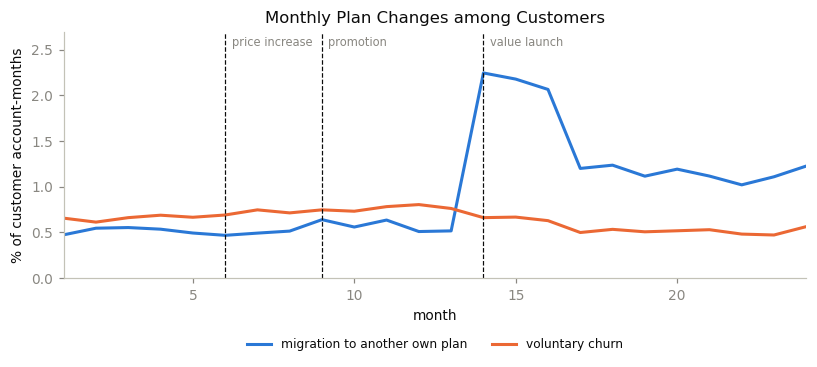

In [8]:
# Plot: Monthly Change Rate
kind = np.where(occasions['outcome'].isin(['premium', 'standard', 'value']), 'migration', 'churn')
rates = (
    occasions.assign(kind = kind).loc[occasions['changed']].groupby(['month', 'kind']).size().unstack(fill_value = 0)
        .div(occasions.groupby('month').size(), axis = 0)
)

fig, ax = plt.subplots(figsize = (7.5, 3.5))
ax.plot(rates.index, rates['migration'] * 100, color = ACCENT, linewidth = 2, label = 'migration to another own plan')
ax.plot(rates.index, rates['churn'] * 100, color = ACCENT2, linewidth = 2, label = 'voluntary churn')
ax.set_ylim(0, rates.max().max() * 100 * 1.2)
price_increase_month = int(list_prices.diff().gt(0).any(axis = 1).idxmax())
for month, label in [(price_increase_month, 'price increase'),
                     (int(promotions['month'].min()), 'promotion'), (int(launch_months.iloc[0]), 'value launch')]:
    ax.axvline(month, color = INK, linewidth = 0.8, linestyle = '--')
    ax.text(month + 0.2, ax.get_ylim()[1] * 0.98, label, fontsize = 7.5, color = MUTED, va = 'top')
ax.set_xlim(1, N_MONTHS)
ax.set_title('Monthly Plan Changes among Customers')
ax.set_xlabel('month')
ax.set_ylabel('% of customer account-months')
ax.legend(frameon = False, fontsize = 8, loc = 'upper center', bbox_to_anchor = (0.5, -0.2), ncol = 2)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>2 · Recovering Demand above the Cap</h2>
<p><strong>Purpose:</strong> Estimates each account's underlying monthly data demand, hotspot need, and roaming days from usage that is censored wherever a plan throttles.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Censored Lognormal Model.</strong> Monthly log demand per line is normal around an account-level mean with a common within-account spread.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>An unthrottled month reveals demand exactly.</li>
<li>A throttled month reveals only that demand exceeded the cap. How much of the excess shows up in usage varies and is not modeled, so the estimate never relies on it.</li>
<li>Fitted by expectation–maximization: throttled months are replaced by their expected value above the cap, then means and spread are re-estimated, until stable.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Partial Pooling.</strong> Account means are shrunk toward the population mean in proportion to how few months an account has, so a short or heavily throttled history does not produce an extreme estimate.</li>
<li style="margin-bottom: 0.7em;"><strong>Hotspot and Roaming.</strong> Hotspot need uses the same model with censoring at the plan's hotspot allowance, for accounts that ever used hotspot. Roaming days are not limited by plan, so rates are empirical Bayes (gamma–Poisson) means.</li>
<li style="margin-bottom: 0.7em;"><strong>Validation without the Answer Key.</strong> Customers who moved from <code>value</code> to a larger plan were censored before the move and much less so after it. Their demand is estimated from pre-move months only and compared with their unthrottled post-move usage, for both the censored model and a naive average of observed usage.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [9]:
# Fit Censored Demand Model
def censored_lognormal(account, log_value, cap, censored, iterations = 60):
    """Account-level lognormal means with a shared spread, from values censored above a cap."""

    ids, index = np.unique(account, return_inverse = True)
    months = np.bincount(index)
    log_cap = np.log(cap)
    mu = np.bincount(index, weights = np.where(censored, log_cap, log_value)) / months
    sigma = np.std(log_value[~censored] - mu[index][~censored])

    for _ in range(iterations):
        m = mu[index]
        with np.errstate(divide = 'ignore', invalid = 'ignore', over = 'ignore'):
            a = (log_cap - m) / sigma
            hazard = norm.pdf(a) / np.clip(norm.sf(a), 1e-12, None)
            filled = np.where(censored, m + sigma * hazard, log_value)
            residual_var = np.where(censored, sigma ** 2 * (1 + a * hazard - hazard ** 2), 0.0)

        raw = np.bincount(index, weights = filled) / months
        grand = raw.mean()
        between = max(raw.var() - np.mean(sigma ** 2 / months), 1e-4)
        mu = (months / sigma ** 2 * raw + grand / between) / (months / sigma ** 2 + 1 / between)
        sigma = np.sqrt(np.mean((filled - mu[index]) ** 2 + residual_var))

    return pd.DataFrame({'account_id': ids, 'mu': mu, 'months': months}), sigma


def empirical_bayes_rate(total, n):
    rate = total / n
    mean, excess = rate.mean(), max(rate.var() - (rate.mean() / n).mean(), 1e-6)
    alpha, beta = mean ** 2 / excess, mean / excess
    return (alpha + total) / (beta + n)


data_cap = usage_panel['plan'].map(plan_catalog['data_gb']).to_numpy()
log_gb = np.log(np.clip(usage_panel['gb_per_line'].to_numpy(), 0.01, None))
data_fit, SIGMA_USAGE = censored_lognormal(
    usage_panel['account_id'].to_numpy(), log_gb, data_cap, usage_panel['throttled'].to_numpy()
)

hotspot_allowance = usage_panel['plan'].map(plan_catalog['hotspot_gb']).to_numpy()
hotspot = usage_panel['hotspot_gb'].to_numpy()
used_hotspot = usage_panel.groupby('account_id')['hotspot_gb'].transform('max').to_numpy() > 0
rows = used_hotspot & (hotspot > 0)
hotspot_fit, SIGMA_HOTSPOT = censored_lognormal(
    usage_panel['account_id'].to_numpy()[rows], np.log(hotspot[rows]),
    hotspot_allowance[rows], hotspot[rows] >= hotspot_allowance[rows] - 0.005,
)

roaming = usage_panel.groupby('account_id').agg(
    months = ('month', 'size'), intl = ('intl_roam_days', 'sum'), na = ('na_roam_days', 'sum')
)
naive_log_gb = usage_panel.assign(log_gb = log_gb).groupby('account_id')['log_gb'].mean()

demand = (
    data_fit.set_index('account_id')
        .join(naive_log_gb.rename('naive_mu'))
        .join(hotspot_fit.set_index('account_id')['mu'].rename('hotspot_mu'))
        .assign(
            hotspot_need = lambda d: np.exp(d['hotspot_mu']).fillna(0.0),
            intl_rate = empirical_bayes_rate(roaming['intl'], roaming['months']),
            na_rate = empirical_bayes_rate(roaming['na'], roaming['months']),
            throttled_share = usage_panel.groupby('account_id')['throttled'].mean(),
            current_plan = usage_panel.sort_values('month').groupby('account_id')['plan'].last(),
        )
)

print(f'Within-account spread of log usage: {SIGMA_USAGE:.3f} · hotspot: {SIGMA_HOTSPOT:.3f}')
display(
    demand.groupby('current_plan').agg(
        accounts = ('mu', 'size'),
        throttled_share = ('throttled_share', 'mean'),
        naive_median_gb = ('naive_mu', lambda x: np.exp(x).median()),
        corrected_median_gb = ('mu', lambda x: np.exp(x).median()),
        hotspot_users = ('hotspot_need', lambda x: (x > 0).mean()),
        intl_days_per_month = ('intl_rate', 'mean'),
    ).reindex(['value', 'standard', 'premium']).round(3).rename_axis(None)
)

Within-account spread of log usage: 0.341 · hotspot: 0.292


,accounts,throttled_share,naive_median_gb,corrected_median_gb,hotspot_users,intl_days_per_month
value,6467,0.184,10.503,10.637,0.395,0.237
standard,27620,0.050,13.199,13.202,0.459,0.321
premium,16840,0.011,15.781,15.760,0.494,0.766


In [10]:
# Validate on Plan Movers
movers = (
    plan_events[(plan_events['event'] == 'migration') & (plan_events['from_plan'] == 'value')
                & plan_events['to_plan'].isin(['standard', 'premium'])]
        .drop_duplicates('account_id')[['account_id', 'month']].rename(columns = {'month': 'move_month'})
)
mover_panel = usage_panel.merge(movers, on = 'account_id')
before = mover_panel[(mover_panel['month'] <= mover_panel['move_month']) & (mover_panel['plan'] == 'value')]
after = mover_panel[(mover_panel['month'] > mover_panel['move_month']) & ~mover_panel['throttled']]

before_fit, _ = censored_lognormal(
    before['account_id'].to_numpy(), np.log(np.clip(before['gb_per_line'].to_numpy(), 0.01, None)),
    before['plan'].map(plan_catalog['data_gb']).to_numpy(), before['throttled'].to_numpy(),
)
comparison = (
    before_fit.set_index('account_id')
        .join(before.assign(log_gb = np.log(np.clip(before['gb_per_line'], 0.01, None))).groupby('account_id')['log_gb'].mean().rename('naive'))
        .join(after.assign(log_gb = np.log(np.clip(after['gb_per_line'], 0.01, None))).groupby('account_id')['log_gb'].mean().rename('after'))
        .dropna()
)
before_throttled = before.groupby('account_id')['throttled'].mean()
comparison['heavily throttled'] = before_throttled.reindex(comparison.index) >= 0.25

validation = pd.DataFrame({
    group: {
        'accounts': len(g),
        'naive average error': (g['naive'] - g['after']).mean(),
        'censored model error': (g['mu'] - g['after']).mean(),
    }
    for group, g in [('all movers', comparison), ('throttled in 25%+ of value months', comparison[comparison['heavily throttled']])]
}).T
display(validation.style.format({'accounts': '{:,.0f}', 'naive average error': '{:+.3f}', 'censored model error': '{:+.3f}'})
        .set_caption('Pre-Move Demand Estimate minus Post-Move Usage (log GB per line)'))

,accounts,naive average error,censored model error
all movers,333,-0.132,-0.082
throttled in 25%+ of value months,227,-0.167,-0.127


<hr>
<div>
<h2>3 · Feature Surplus from Estimated Demand</h2>
<p><strong>Purpose:</strong> Converts each alternative's attributes into account-specific costs, so a feature's value depends on the account's own needs rather than being the same for everyone.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Throttle.</strong> Expected GB per line above the plan's cap each month, <code>E[max(0, D − cap)]</code> for lognormal demand, in closed form. Unlimited plans cost nothing.</li>
<li style="margin-bottom: 0.7em;"><strong>Hotspot Gap.</strong> Estimated hotspot need the plan's allowance does not cover.</li>
<li style="margin-bottom: 0.7em;"><strong>Roaming Gap.</strong> Expected roaming days per month the plan does not cover: international days unless the plan includes international roaming, North America days unless it includes at least North America.</li>
<li style="margin-bottom: 0.7em;"><strong>Plan-Level Features.</strong> Streaming quality and perks are the same for every account on a plan, so they are not surplus terms; section 5 shows why history cannot value them.</li>
<li style="margin-bottom: 0.7em;"><strong>Look-Ahead.</strong> Demand is estimated from each account's full 24 months, so an occasion's features use some later months. That is acceptable for a baseline; section 05 refits on pre-launch months only.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [11]:
# Compute Feature Surplus
def throttled_gb(mu, cap, sigma):
    mu, cap = np.broadcast_arrays(np.asarray(mu, dtype = float), np.asarray(cap, dtype = float))
    finite = np.isfinite(cap)
    safe_cap = np.where(finite, cap, 1.0)
    d = (mu - np.log(safe_cap)) / sigma
    expected = np.exp(mu + sigma ** 2 / 2) * norm.cdf(d + sigma) - safe_cap * norm.cdf(d)
    return np.where(finite, np.maximum(expected, 0.0), 0.0)


def feature_surplus(demand, catalog, mu_column = 'mu', sigma = None):
    sigma = SIGMA_USAGE if sigma is None else sigma
    roaming_tier = catalog['roaming_tier'].to_numpy()[None, :]
    return {
        'throttle': throttled_gb(demand[mu_column].to_numpy()[:, None], catalog['data_gb'].to_numpy()[None, :], sigma),
        'hotspot': np.maximum(demand['hotspot_need'].to_numpy()[:, None] - catalog['hotspot_gb'].to_numpy()[None, :], 0.0),
        'roam': demand['intl_rate'].to_numpy()[:, None] * (roaming_tier < 2) + demand['na_rate'].to_numpy()[:, None] * (roaming_tier < 1),
    }

rp_catalog = plan_catalog.loc[RP_ALTS]
surplus = feature_surplus(demand, rp_catalog)
naive_surplus = feature_surplus(demand, rp_catalog, mu_column = 'naive_mu')
surplus_row = pd.Series(np.arange(len(demand)), index = demand.index)

by_plan = demand['current_plan'].to_numpy()
surplus_table = pd.concat({
    'throttled GB under value (naive)': pd.Series(naive_surplus['throttle'][:, ALT_INDEX['value']]).groupby(by_plan).mean(),
    'throttled GB under value (corrected)': pd.Series(surplus['throttle'][:, ALT_INDEX['value']]).groupby(by_plan).mean(),
    'throttled GB under standard (corrected)': pd.Series(surplus['throttle'][:, ALT_INDEX['standard']]).groupby(by_plan).mean(),
    'hotspot gap under value (GB)': pd.Series(surplus['hotspot'][:, ALT_INDEX['value']]).groupby(by_plan).mean(),
    'roaming gap under standard (days)': pd.Series(surplus['roam'][:, ALT_INDEX['standard']]).groupby(by_plan).mean(),
}, axis = 1).reindex(['value', 'standard', 'premium'])
display(surplus_table.rename_axis('current plan').style.format('{:.2f}').set_caption('Mean Feature Surplus by Current Plan'))

,throttled GB under value (naive),throttled GB under value (corrected),throttled GB under standard (corrected),hotspot gap under value (GB),roaming gap under standard (days)
current plan,,,,,
value,3.56,4.51,0.45,0.92,0.24
standard,6.94,7.18,0.92,1.49,0.32
premium,13.61,13.49,4.35,2.06,0.77


<hr>
<div>
<h2>4 · Destination and Switching Models</h2>
<p><strong>Purpose:</strong> Fits the two-part baseline: where customers go when they change, and how likely they are to change at all.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Why Two Parts.</strong> In a single logit over all account-months, the customers who never re-shopped dominate, and their indifference to price is read as low price sensitivity for everyone. Conditioning on a change removes whether a customer looked from the choice among alternatives.</li>
<li style="margin-bottom: 0.7em;"><strong>Destination Logit.</strong> Among occasions that ended in a change, the current plan is excluded and the customer chooses among the rest.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Utility: per-line price, throttle, hotspot gap, roaming gap, and alternative × line-count constants (<code>outside</code> is the reference).</li>
<li>Line-count constants absorb differences between household types, so price is identified by the month-6 increase, the promotion, and the <code>value</code> launch rather than by who has more lines.</li>
<li>A port-out counts as a choice of either competitor plan: the likelihood uses the combined probability of the two.</li>
<li>Standard errors are robust (sandwich) estimates.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Switching Logit.</strong> A binary logit on all occasions with the five triggers and the gain from the best alternative: the log-sum of destination utilities minus the current plan's utility under the same coefficients.</li>
<li style="margin-bottom: 0.7em;"><strong>Holdout.</strong> 20% of accounts are withheld from both fits and used only to check predictions.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [12]:
# Split Accounts for Holdout
rng = np.random.default_rng(SEED)
account_ids = occasions['account_id'].unique()
holdout_accounts = set(account_ids[rng.random(len(account_ids)) < 0.2])
occasions['holdout'] = occasions['account_id'].isin(holdout_accounts)
print(f'{len(holdout_accounts):,} holdout accounts · {occasions["holdout"].mean():.1%} of occasions')

10,242 holdout accounts · 20.2% of occasions


In [13]:
# Define Choice Design
DESTINATION_FEATURES = ['price', 'throttle', 'hotspot', 'roam']
CONSTANTS = [f'{a} × {l} lines' for a in RP_ALTS[:-1] for l in range(1, 6)]
DISCOUNTED = rp_catalog['multiline_discount'].to_numpy()


def choice_design(o, constants = 'plan × lines'):
    """Features (n, J, K), availability (n, J), and chosen set (n, J) for choice occasions."""

    n, J = len(o), len(RP_ALTS)
    lines = o['lines'].to_numpy()
    list_price = list_prices.loc[o['month']].to_numpy()
    discount = discounts.reindex(pd.MultiIndex.from_frame(o[['market_id', 'month']])).fillna(0.0).to_numpy()
    price = (list_price - discount) * np.where(DISCOUNTED[None, :], multiline_factor(lines)[:, None], 1.0)

    row = surplus_row.loc[o['account_id']].to_numpy()
    columns = [price, surplus['throttle'][row], surplus['hotspot'][row], surplus['roam'][row]]
    alt = np.arange(J)[None, :]
    if constants == 'plan × lines':
        columns += [((alt == ALT_INDEX[a]) & (lines == l)[:, None]).astype(float) for a in RP_ALTS[:-1] for l in range(1, 6)]
    else:
        columns += [np.broadcast_to(alt == ALT_INDEX[a], (n, J)).astype(float) for a in RP_ALTS[:-1]]

    available_now = available.loc[o['month']].to_numpy()
    outcome = o['outcome'].to_numpy()
    chosen = np.zeros((n, J), dtype = bool)
    for a in RP_ALTS:
        target = 'competitor' if a.startswith('comp_') else a
        chosen[outcome == target, ALT_INDEX[a]] = True

    return np.stack(columns, axis = 2), available_now, chosen


def fit_set_logit(X, available, chosen, weight = None):
    """Conditional logit where the chosen outcome may be a set of alternatives; robust standard errors."""

    n, J, K = X.shape
    weight = np.ones(n) if weight is None else weight

    def probabilities(b):
        V = np.where(available, X @ b, -np.inf)
        P = softmax(V, axis = 1)
        Vc = np.where(chosen, V, -np.inf)
        Q = np.where(chosen, softmax(Vc, axis = 1), 0.0)
        return V, Vc, P, Q

    def objective(b):
        V, Vc, P, Q = probabilities(b)
        loglik = logsumexp(Vc, axis = 1) - logsumexp(V, axis = 1)
        gradient = np.einsum('n,nj,njk->k', weight, Q - P, X)
        return -(weight * loglik).sum(), -gradient

    result = minimize(objective, np.zeros(K), jac = True, method = 'L-BFGS-B', options = {'maxiter': 5000})
    _, _, P, Q = probabilities(result.x)
    xp, xq = np.einsum('nj,njk->nk', P, X), np.einsum('nj,njk->nk', Q, X)
    H = sum(((weight * (P[:, j] - Q[:, j]))[:, None] * X[:, j]).T @ X[:, j] for j in range(J))
    H -= (weight[:, None] * xp).T @ xp - (weight[:, None] * xq).T @ xq
    G = (xq - xp) * weight[:, None]
    H_inv = np.linalg.pinv(H)
    se = np.sqrt(np.diag(H_inv @ (G.T @ G) @ H_inv))

    return result, pd.DataFrame({'estimate': result.x, 'std error': se, 't': result.x / se})

In [14]:
# Fit Destination Model
changes = occasions[occasions['changed'] & ~occasions['holdout']]
X_dest, available_dest, chosen_dest = choice_design(changes)
available_dest[np.arange(len(changes)), changes['plan'].map(ALT_INDEX).to_numpy()] = False

destination_fit, destination_coefficients = fit_set_logit(X_dest, available_dest, chosen_dest)
destination_coefficients.index = DESTINATION_FEATURES + CONSTANTS
b_destination = destination_coefficients['estimate'].to_numpy()
print(f'{len(changes):,} changes · {destination_fit.message}')

display(destination_coefficients.loc[DESTINATION_FEATURES].style.format('{:.4f}').set_caption('Destination Model: Price and Feature Coefficients'))

price_coef = destination_coefficients.loc['price', 'estimate']
display(pd.DataFrame({
    'implied value': [
        destination_coefficients.loc['throttle', 'estimate'] / price_coef,
        destination_coefficients.loc['hotspot', 'estimate'] / price_coef,
        destination_coefficients.loc['roam', 'estimate'] / price_coef,
    ],
}, index = ['avoid 1 GB throttled per line', 'cover 1 GB of hotspot need', 'cover 1 roaming day']).style.format('${:,.2f}')
    .set_caption('Implied Willingness to Pay per Line per Month'))

12,796 changes · CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


,estimate,std error,t
price,-0.0218,0.0099,-2.2102
throttle,-0.0522,0.0022,-23.8841
hotspot,-0.0888,0.0062,-14.2155
roam,-0.7827,0.0544,-14.3966


,implied value
avoid 1 GB throttled per line,$2.39
cover 1 GB of hotspot need,$4.07
cover 1 roaming day,$35.88


In [15]:
# Fit Switching Model
def gain_from_best_alternative(o, b, chunk = 100_000):
    gain = np.empty(len(o))
    for start in range(0, len(o), chunk):
        part = o.iloc[start:start + chunk]
        X, available_now, _ = choice_design(part)
        V = np.where(available_now, X @ b, -np.inf)
        rows, current = np.arange(len(part)), part['plan'].map(ALT_INDEX).to_numpy()
        current_utility = V[rows, current]
        V[rows, current] = -np.inf
        gain[start:start + chunk] = logsumexp(V, axis = 1) - current_utility
    return gain

occasions['gain'] = gain_from_best_alternative(occasions, b_destination)
SWITCH_TERMS = ['intercept'] + TRIGGERS + ['gain from best alternative']


def switching_design(o):
    return np.column_stack([np.ones(len(o)), o[TRIGGERS].to_numpy(dtype = float), o['gain'].to_numpy()])


def fit_binary_logit(Z, y):
    def objective(b):
        eta = Z @ b
        return -(y * eta - np.logaddexp(0, eta)).sum(), -(Z.T @ (y - 1 / (1 + np.exp(-eta))))
    result = minimize(objective, np.zeros(Z.shape[1]), jac = True, method = 'L-BFGS-B')
    p = 1 / (1 + np.exp(-(Z @ result.x)))
    se = np.sqrt(np.diag(np.linalg.inv((Z * (p * (1 - p))[:, None]).T @ Z)))
    return result, pd.DataFrame({'estimate': result.x, 'std error': se, 't': result.x / se})

fit_rows = ~occasions['holdout']
switching_fit, switching_coefficients = fit_binary_logit(
    switching_design(occasions[fit_rows]), occasions.loc[fit_rows, 'changed'].to_numpy(dtype = float)
)
switching_coefficients.index = SWITCH_TERMS
b_switching = switching_coefficients['estimate'].to_numpy()
display(switching_coefficients.style.format('{:.3f}').set_caption('Switching Model'))

,estimate,std error,t
intercept,-4.633,0.015,-300.449
device_upgrade,1.057,0.035,30.097
throttled_last_month,0.849,0.033,25.882
care_contact,0.783,0.038,20.739
promo,0.202,0.040,4.991
launch_window,0.595,0.022,26.574
gain from best alternative,0.295,0.011,27.227


,premium,standard,value,competitor,outside
observed,15.2%,18.1%,25.1%,31.7%,9.9%
predicted,16.1%,17.3%,26.1%,30.6%,9.9%


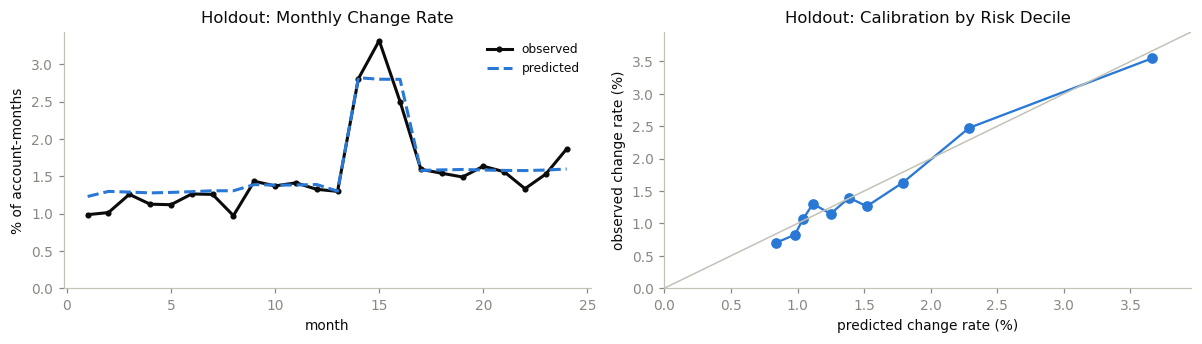

In [16]:
# Validate on Holdout Accounts
holdout = occasions[occasions['holdout']].copy()
holdout['p_change'] = 1 / (1 + np.exp(-(switching_design(holdout) @ b_switching)))

holdout_changes = holdout[holdout['changed']]
X_h, available_h, _ = choice_design(holdout_changes)
available_h[np.arange(len(holdout_changes)), holdout_changes['plan'].map(ALT_INDEX).to_numpy()] = False
P_h = softmax(np.where(available_h, X_h @ b_destination, -np.inf), axis = 1)
predicted = pd.Series(P_h.mean(axis = 0), index = RP_ALTS)
predicted = pd.concat([predicted.drop(['comp_premium', 'comp_value']), pd.Series({'competitor': predicted[['comp_premium', 'comp_value']].sum()})])
display(pd.DataFrame({
    'observed': holdout_changes['outcome'].value_counts(normalize = True), 'predicted': predicted
}).reindex(['premium', 'standard', 'value', 'competitor', 'outside']).T.style.format('{:.1%}')
    .set_caption('Holdout: Destination Shares among Changes'))

holdout['risk decile'] = pd.qcut(holdout['p_change'], 10, labels = False) + 1
calibration = holdout.groupby('risk decile')[['p_change', 'changed']].mean()

fig, axes = plt.subplots(1, 2, figsize = (11, 3.2))
by_month = holdout.groupby('month')[['changed', 'p_change']].mean() * 100
axes[0].plot(by_month.index, by_month['changed'], color = INK, linewidth = 2, marker = 'o', markersize = 3, label = 'observed')
axes[0].plot(by_month.index, by_month['p_change'], color = ACCENT, linewidth = 2, linestyle = '--', label = 'predicted')
axes[0].set_ylim(bottom = 0)
axes[0].set_title('Holdout: Monthly Change Rate')
axes[0].set_xlabel('month')
axes[0].set_ylabel('% of account-months')
axes[0].legend(frameon = False, fontsize = 8)

axes[1].plot(calibration['p_change'] * 100, calibration['changed'] * 100, color = ACCENT, marker = 'o', linewidth = 1.5)
edge = calibration[['p_change', 'changed']].max().max() * 100 * 1.08
axes[1].plot([0, edge], [0, edge], color = BASELINE, linewidth = 1)
axes[1].set_xlim(0, edge)
axes[1].set_ylim(0, edge)
axes[1].set_title('Holdout: Calibration by Risk Decile')
axes[1].set_xlabel('predicted change rate (%)')
axes[1].set_ylabel('observed change rate (%)')

plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · What History Cannot Identify</h2>
<p><strong>Purpose:</strong> Documents where revealed choices run out, so the later sections know which quantities must come from the conjoint.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Plan-Level Features.</strong> Streaming tier and perks value are identical for everyone on a plan. Added to the destination design, they are exact linear combinations of the plan constants, which the rank of the design matrix confirms.</li>
<li style="margin-bottom: 0.7em;"><strong>Price.</strong> The destination model is refitted with plan constants only. Without line-count constants, price is also identified by differences between one-line and multi-line households, which differ in who they are as well as in what they pay. The comparison shows how much of the precision rests on that.</li>
<li style="margin-bottom: 0.7em;"><strong>Acquisition and Competitor Plans.</strong> Only customers' choices are observed, and port-outs do not record the competitor plan; neither can be recovered from this history.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [17]:
# Test Identification
plan_level = np.stack([
    np.broadcast_to(rp_catalog['stream_tier'].to_numpy(dtype = float), X_dest.shape[:2]),
    np.broadcast_to(rp_catalog['perks_value'].to_numpy(dtype = float), X_dest.shape[:2]),
], axis = 2)
with_plan_level = np.concatenate([X_dest, plan_level], axis = 2)
flat = lambda X: (X - X.mean(axis = 1, keepdims = True)).reshape(-1, X.shape[2])
rank_before, rank_after = np.linalg.matrix_rank(flat(X_dest)), np.linalg.matrix_rank(flat(with_plan_level))

X_plan_only, _, _ = choice_design(changes, constants = 'plan only')
_, plan_only_coefficients = fit_set_logit(X_plan_only, available_dest, chosen_dest)
plan_only_coefficients.index = DESTINATION_FEATURES + [f'{a}' for a in RP_ALTS[:-1]]

identification = pd.DataFrame([
    ('Streaming tier and perks',
     f'No: adding both columns left the design rank at {rank_after}' if rank_after == rank_before
     else f'Partly: adding both columns raised the design rank from {rank_before} to {rank_after}', 'Conjoint (section 02)'),
    ('Price, plan × line-count constants',
     f"Weakly: t = {destination_coefficients.loc['price', 't']:.1f}", 'Joint RP–SP model (section 03)'),
    ('Price, plan constants only',
     f"Precisely (t = {plan_only_coefficients.loc['price', 't']:.1f}), but mixed with household type", 'Not used'),
    ('Throttle, hotspot, and roaming gaps',
     f"Yes: |t| ≥ {destination_coefficients.loc[['throttle', 'hotspot', 'roam'], 't'].abs().min():.0f}, varies across accounts on the same plan", 'Carried forward'),
    ('Acquisition from competitors and outside', 'No: non-customers\' choices are not observed', 'Conjoint non-customer sample'),
    ('Which competitor plan a churner chose', 'No: port-outs record only the carrier', 'Competitor constants from the joint model'),
], columns = ['quantity', 'identified from history?', 'where it comes from instead'])
display(identification.style.hide(axis = 'index').set_caption('What Revealed Choices Identify'))

quantity,identified from history?,where it comes from instead
Streaming tier and perks,No: adding both columns left the design rank at 29,Conjoint (section 02)
"Price, plan × line-count constants",Weakly: t = -2.2,Joint RP–SP model (section 03)
"Price, plan constants only","Precisely (t = -13.1), but mixed with household type",Not used
"Throttle, hotspot, and roaming gaps","Yes: |t| ≥ 14, varies across accounts on the same plan",Carried forward
Acquisition from competitors and outside,No: non-customers' choices are not observed,Conjoint non-customer sample
Which competitor plan a churner chose,No: port-outs record only the carrier,Competitor constants from the joint model


<hr>
<div>
<h2>6 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Saves the inputs and estimates that sections 03 and 05 build on.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li><code>demand_estimates</code>: per-account demand mean, hotspot need, and roaming rates, with the shared spreads in <code>rp_meta</code></li>
<li><code>prices_faced</code>: recovered promotions by market, month, and plan</li>
<li><code>choice_occasions</code>: every occasion with outcome, triggers, gain, and holdout flag</li>
<li><code>rp_destination_coefficients</code> and <code>rp_switching_coefficients</code>: the baseline estimates with robust standard errors</li>
</ol>
</div>

In [18]:
# Export Section 01 Outputs
exports = {
    'demand_estimates': demand.drop(columns = ['naive_mu']).reset_index(),
    'prices_faced': discounts.reset_index(),
    'choice_occasions': occasions,
    'rp_destination_coefficients': destination_coefficients.rename_axis('term').reset_index(),
    'rp_switching_coefficients': switching_coefficients.rename_axis('term').reset_index(),
    'rp_meta': pd.DataFrame({
        'key': ['sigma_usage', 'sigma_hotspot', 'holdout_seed', 'holdout_share'],
        'value': [SIGMA_USAGE, SIGMA_HOTSPOT, SEED, 0.2],
    }),
}
paths = [save_output(df, name) for name, df in exports.items()]
display(pd.DataFrame({'rows': [len(df) for df in exports.values()], 'size (MB)': [round(p.stat().st_size / 1e6, 2) for p in paths]},
                     index = [p.name for p in paths]).rename_axis(None))

,rows,size (MB)
demand_estimates.parquet,50927,1.53
prices_faced.parquet,960,0.01
choice_occasions.parquet,1012958,4.09
rp_destination_coefficients.parquet,29,0.00
rp_switching_coefficients.parquet,7,0.00
rp_meta.parquet,4,0.00


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>02 · The Stated-Preference Mixed Logit</h1>
<p><strong>Purpose:</strong> Estimates how much respondents value each plan feature relative to price, and how much those valuations vary between people, from the conjoint survey. This is the only source of variation in features independent of price, and the only way to value a plan nobody has seen.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Raking weights for customer respondents</td><td style="text-align: left; vertical-align: top;">Some customer types answer surveys more often; unweighted estimates would describe the respondents rather than the base.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Respondent demand from the panel or calibrated self-reports</td><td style="text-align: left; vertical-align: top;">Throttle, hotspot, and roaming costs depend on each respondent's own needs, which must be estimated for non-customers who have no usage history.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Panel mixed logit by simulated maximum likelihood (scipy L-BFGS-B, analytic gradients, scrambled Halton draws)</td><td style="text-align: left; vertical-align: top;">Coefficients vary across respondents but stay fixed across one respondent's tasks. A lognormal price coefficient keeps price sensitivity negative for everyone.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4</td><td style="text-align: left; vertical-align: top;">Holdout-task validation against a fixed-coefficient logit</td><td style="text-align: left; vertical-align: top;">Two fixed tasks excluded from estimation test whether the model predicts choices it has not seen, and whether allowing tastes to vary is worth it.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">5</td><td style="text-align: left; vertical-align: top;">Individual-level conditional part-worths</td><td style="text-align: left; vertical-align: top;">Each respondent's own choices sharpen the population distribution into a person-level estimate, used later to link tastes to observable data.</td></tr>
</tbody>
</table>
</div>

In [19]:
# Load Conjoint
conjoint = load('conjoint_responses')
conjoint_respondents = load('conjoint_respondents').set_index('respondent_id')
demand_estimates = load_output('demand_estimates').set_index('account_id')
SIGMA_USAGE = load_output('rp_meta').set_index('key').loc['sigma_usage', 'value']

print(
    f'{len(conjoint_respondents):,} respondents · '
    f'{conjoint.loc[~conjoint.is_holdout, "task"].nunique()} estimation tasks + '
    f'{conjoint.loc[conjoint.is_holdout, "task"].nunique()} holdout tasks each · '
    f'{conjoint_respondents.is_customer.mean():.0%} current customers'
)

4,000 respondents · 10 estimation tasks + 2 holdout tasks each · 75% current customers


<hr>
<div>
<h2>1 · Sample Reweighting for Response Bias</h2>
<p><strong>Purpose:</strong> Weights customer respondents so their mix matches the month-24 customer base on the fields the carrier holds.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Raking.</strong> Iterative proportional fitting on four margins at once: lines, age band, local income tier, and device tier. Weights are trimmed to 0.3–3× to keep a few respondents from dominating.</li>
<li style="margin-bottom: 0.7em;"><strong>Non-Customers.</strong> The carrier has no record of competitor or outside households to weight against, so they keep equal weights. Any response bias among them is left uncorrected and disclosed.</li>
<li style="margin-bottom: 0.7em;"><strong>Limits.</strong> Weighting can only correct bias that runs through observable fields. If some customers answer surveys more often because of tastes those fields do not capture, part of that bias remains.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [20]:
# Rake Customer Respondents
RAKING_MARGINS = ['lines', 'age_band', 'zip_income_tier', 'device_tier']

base_ids = load('usage_panel').query('month == @N_MONTHS')['account_id']
customer_base = load('accounts').set_index('account_id').loc[base_ids]
customers = conjoint_respondents[conjoint_respondents['is_customer']]


def rake(sample, population, margins, iterations = 50, trim = (0.3, 3.0)):
    weight = pd.Series(1.0, index = sample.index)
    targets = {m: population[m].value_counts(normalize = True) for m in margins}
    for _ in range(iterations):
        for m in margins:
            current = weight.groupby(sample[m]).sum() / weight.sum()
            weight *= sample[m].map(targets[m] / current)
        weight = weight.clip(*trim)
        weight /= weight.mean()
    return weight

conjoint_respondents['weight'] = 1.0
conjoint_respondents.loc[customers.index, 'weight'] = rake(customers, customer_base, RAKING_MARGINS)

margin_check = pd.concat([
    pd.DataFrame({
        'customer base': customer_base[m].value_counts(normalize = True),
        'respondents, unweighted': customers[m].value_counts(normalize = True),
        'respondents, weighted': conjoint_respondents.loc[customers.index].groupby(m)['weight'].sum() / len(customers),
    }).rename(index = lambda v: f'{m} = {v}')
    for m in RAKING_MARGINS
])
display(margin_check.style.format('{:.1%}').set_caption('Customer Respondents vs Customer Base'))

w_c = conjoint_respondents.loc[customers.index, 'weight']
print(f'Customer weights range {w_c.min():.2f}–{w_c.max():.2f} · effective sample size {w_c.sum() ** 2 / (w_c ** 2).sum():,.0f} of {len(w_c):,}')

,customer base,"respondents, unweighted","respondents, weighted"
lines = 1,30.1%,30.4%,30.1%
lines = 2,31.0%,28.5%,31.0%
lines = 3,19.3%,19.7%,19.3%
lines = 4,13.0%,14.6%,13.0%
lines = 5,6.6%,6.8%,6.6%
age_band = 18-29,21.7%,20.7%,21.7%
age_band = 30-44,29.9%,29.8%,29.9%
age_band = 45-64,32.0%,33.6%,32.0%
age_band = 65+,16.4%,15.9%,16.4%
zip_income_tier = high,28.7%,30.5%,28.7%


Customer weights range 0.79–1.19 · effective sample size 2,978 of 3,000


<hr>
<div>
<h2>2 · Model Specification and Halton Draws</h2>
<p><strong>Purpose:</strong> Builds each respondent's feature values for every profile, and sets the coefficient distributions and simulation draws.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Respondent Demand.</strong> Throttle, hotspot, and roaming costs use the same definitions as section 01.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Customers with a usage history use their section 01 estimates.</li>
<li>Everyone else uses self-reports, calibrated on customers who both reported and were observed: log demand regressed on log reported GB, and roaming days regressed on reported trips per year. This corrects systematic under-reporting rather than taking reports at face value.</li>
<li>Hotspot need and North America roaming, which the survey does not ask about, are the customer averages by device tier and by age band.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Utility.</strong> Per-line price, expected throttled GB, hotspot gap, roaming gap, streaming tier, perks value, and a keep-current constant, all random across respondents. Non-customers get two fixed shifts: in the keep-current constant, and in the log of the price coefficient, since households already with competitors or outside postpaid may be more price-sensitive than customers as a group.</li>
<li style="margin-bottom: 0.7em;"><strong>Distributions.</strong> Price is lognormal and negative; the other coefficients are normal and independent. Independence is a simplification: tastes that move together, such as roaming and perks among frequent travelers, are the subject of section 04.</li>
<li style="margin-bottom: 0.7em;"><strong>Draws.</strong> Scrambled Halton sequences, which cover the distribution more evenly than pseudo-random draws, so fewer are needed for a stable likelihood. Each respondent gets their own draws, held fixed across their tasks.</li>
<li style="margin-bottom: 0.7em;"><strong>Scaling.</strong> Price and perks enter per &#36;10 during estimation to keep the optimizer well conditioned; every reported coefficient is converted back to per-dollar units.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

,intercept,slope,R²
log demand ~ log reported GB,0.760,0.759,0.752
international days per month ~ reported trips per year,0.109,0.259,0.793


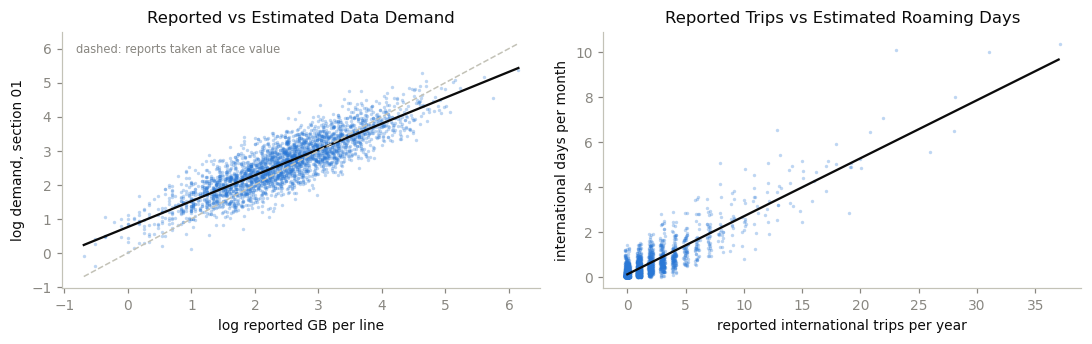

In [21]:
# Build Respondent Demand
respondents = conjoint_respondents.copy()
respondents['log_reported_gb'] = np.log(respondents['reported_gb_per_line'].clip(lower = 0.1))
has_panel = respondents['is_customer'] & respondents.index.isin(demand_estimates.index)
calibration = respondents[has_panel].join(demand_estimates[['mu', 'intl_rate', 'na_rate', 'hotspot_need']])


def least_squares(x, y):
    A = np.column_stack([np.ones(len(x)), x])
    coef = np.linalg.lstsq(A, y, rcond = None)[0]
    return coef, 1 - np.var(y - A @ coef) / np.var(y)

gb_coef, gb_r2 = least_squares(calibration['log_reported_gb'], calibration['mu'])
trip_coef, trip_r2 = least_squares(calibration['reported_intl_trips_per_year'], calibration['intl_rate'])

respondent_demand = pd.DataFrame(index = respondents.index)
respondent_demand['source'] = np.where(has_panel, 'usage panel', 'calibrated self-report')
respondent_demand['mu'] = np.where(
    has_panel, demand_estimates['mu'].reindex(respondents.index), gb_coef[0] + gb_coef[1] * respondents['log_reported_gb']
)
respondent_demand['intl_rate'] = np.where(
    has_panel, demand_estimates['intl_rate'].reindex(respondents.index),
    np.clip(trip_coef[0] + trip_coef[1] * respondents['reported_intl_trips_per_year'], 0, None),
)
respondent_demand['hotspot_need'] = np.where(
    has_panel, demand_estimates['hotspot_need'].reindex(respondents.index),
    respondents['device_tier'].map(calibration.groupby('device_tier')['hotspot_need'].mean()),
)
respondent_demand['na_rate'] = np.where(
    has_panel, demand_estimates['na_rate'].reindex(respondents.index),
    respondents['age_band'].map(calibration.groupby('age_band')['na_rate'].mean()),
)

display(pd.DataFrame({
    'intercept': [gb_coef[0], trip_coef[0]], 'slope': [gb_coef[1], trip_coef[1]], 'R²': [gb_r2, trip_r2],
}, index = ['log demand ~ log reported GB', 'international days per month ~ reported trips per year'])
    .style.format('{:.3f}').set_caption(f'Self-Report Calibration on {len(calibration):,} Customer Respondents'))

fig, axes = plt.subplots(1, 2, figsize = (10, 3.2))
axes[0].scatter(calibration['log_reported_gb'], calibration['mu'], s = 5, alpha = 0.3, color = ACCENT, linewidths = 0)
grid = np.linspace(calibration['log_reported_gb'].min(), calibration['log_reported_gb'].max(), 50)
axes[0].plot(grid, gb_coef[0] + gb_coef[1] * grid, color = INK, linewidth = 1.5)
axes[0].plot(grid, grid, color = BASELINE, linewidth = 1, linestyle = '--')
axes[0].set_title('Reported vs Estimated Data Demand')
axes[0].set_xlabel('log reported GB per line')
axes[0].set_ylabel('log demand, section 01')
axes[0].text(0.03, 0.92, 'dashed: reports taken at face value', transform = axes[0].transAxes, fontsize = 7.5, color = MUTED)

axes[1].scatter(calibration['reported_intl_trips_per_year'] + np.random.default_rng(1).uniform(-0.2, 0.2, len(calibration)),
                calibration['intl_rate'], s = 5, alpha = 0.3, color = ACCENT, linewidths = 0)
trips = np.arange(0, calibration['reported_intl_trips_per_year'].max() + 1)
axes[1].plot(trips, trip_coef[0] + trip_coef[1] * trips, color = INK, linewidth = 1.5)
axes[1].set_title('Reported Trips vs Estimated Roaming Days')
axes[1].set_xlabel('reported international trips per year')
axes[1].set_ylabel('international days per month')
plt.tight_layout()
plt.show()

In [22]:
# Build Conjoint Design
SP_RANDOM = ['price', 'throttle', 'hotspot', 'roam', 'stream', 'perks', 'keep_current']
SP_FIXED = ['keep_current × non-customer']
SP_SCALE = np.array([10.0, 1.0, 1.0, 1.0, 1.0, 10.0, 1.0, 1.0])
LOGNORMAL = np.array([True, False, False, False, False, False, False])
K_RANDOM = len(SP_RANDOM)
N_TASKS, N_OPTIONS = 10, 4

sp = conjoint.sort_values(['respondent_id', 'task', 'option']).reset_index(drop = True)
demand_rows = respondent_demand.loc[sp['respondent_id']]
roaming_tier = sp['roaming_tier'].to_numpy()
sp_features = pd.DataFrame({
    'price': sp['price_per_line'].to_numpy(),
    'throttle': throttled_gb(demand_rows['mu'].to_numpy(), sp['data_gb'].to_numpy(), SIGMA_USAGE),
    'hotspot': np.maximum(demand_rows['hotspot_need'].to_numpy() - sp['hotspot_gb'].to_numpy(), 0.0),
    'roam': demand_rows['intl_rate'].to_numpy() * (roaming_tier < 2) + demand_rows['na_rate'].to_numpy() * (roaming_tier < 1),
    'stream': sp['stream_tier'].to_numpy(),
    'perks': sp['perks_value'].to_numpy(),
    'keep_current': sp['option'].eq('keep_current').to_numpy(dtype = float),
})
sp_features['keep_current × non-customer'] = sp_features['keep_current'] * (~respondents['is_customer'].reindex(sp['respondent_id']).to_numpy())

sp_respondent_ids = np.sort(sp['respondent_id'].unique())
sp_weights = respondents.loc[sp_respondent_ids, 'weight'].to_numpy()


def to_panel(rows, n_tasks):
    X = (sp_features.loc[rows, SP_RANDOM + SP_FIXED].to_numpy() / SP_SCALE).reshape(len(sp_respondent_ids), n_tasks, N_OPTIONS, -1)
    y = sp.loc[rows, 'chosen'].to_numpy().reshape(len(sp_respondent_ids), n_tasks, N_OPTIONS).argmax(axis = 2)
    return X, y

X_sp, y_sp = to_panel(~sp['is_holdout'], N_TASKS)
X_holdout, y_holdout = to_panel(sp['is_holdout'], 2)


def halton_normal(n, draws, dims, seed):
    uniform = qmc.Halton(d = dims, scramble = True, seed = seed).random(n * draws)
    return norm.ppf(np.clip(uniform, 1e-10, 1 - 1e-10)).reshape(n, draws, dims)

print(f'Estimation panel {X_sp.shape} (respondents, tasks, options, terms) · holdout panel {X_holdout.shape}')

Estimation panel (4000, 10, 4, 8) (respondents, tasks, options, terms) · holdout panel (4000, 2, 4, 8)


<hr>
<div>
<h2>3 · Simulated Maximum Likelihood</h2>
<p><strong>Purpose:</strong> Fits the mixed logit, checks that the estimates hold as the number of draws grows, and reports robust standard errors.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Likelihood.</strong> For each draw, the probability of a respondent's full sequence of 10 choices is the product of logit probabilities; the respondent's likelihood averages that over draws. Weights multiply each respondent's log-likelihood.</li>
<li style="margin-bottom: 0.7em;"><strong>Gradient.</strong> Computed analytically, draw by draw, including the lognormal price transform, and verified against finite differences before fitting.</li>
<li style="margin-bottom: 0.7em;"><strong>Draw Stability.</strong> The model is fitted with 100 draws, then refitted from that solution with 250. Estimates that move materially between the two would mean the simulation, not the data, is driving them.</li>
<li style="margin-bottom: 0.7em;"><strong>Standard Errors.</strong> A sandwich estimator from per-respondent scores, which accounts for the weights. The sign of a standard-deviation parameter is not identified, so its absolute value is reported.</li>
<li style="margin-bottom: 0.7em;"><strong>Survey Bias Remains.</strong> These are stated-preference coefficients. The survey's scale and any understatement of price sensitivity carry through to willingness to pay here; section 03 corrects them against real choices.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [23]:
# Define Mixed Logit Likelihood
def random_coefficients(theta, Z, noncustomer):
    raw = theta[:K_RANDOM] + theta[K_RANDOM:2 * K_RANDOM] * Z
    raw[..., 0] += theta[2 * K_RANDOM + len(SP_FIXED)] * noncustomer[:, None]
    return np.where(LOGNORMAL, -np.exp(raw), raw)


def mixed_logit(theta, X, y, Z, weight, noncustomer, scores = False, chunk = 1000):
    """Weighted simulated log-likelihood of a panel mixed logit, its gradient, and optionally per-respondent scores."""

    n_resp, n_draws, _ = Z.shape
    fixed = theta[2 * K_RANDOM:2 * K_RANDOM + len(SP_FIXED)]
    loglik, gradient = 0.0, np.zeros_like(theta)
    score_rows = []

    for start in range(0, n_resp, chunk):
        part = slice(start, start + chunk)
        X_c, y_c, Z_c, w_c, nc_c = X[part], y[part], Z[part], weight[part], noncustomer[part]

        beta = random_coefficients(theta, Z_c, nc_c)
        V = np.einsum('ntjk,nrk->ntjr', X_c[..., :K_RANDOM], beta) + np.einsum('ntjk,k->ntj', X_c[..., K_RANDOM:], fixed)[..., None]
        P = softmax(V, axis = 2)
        P_chosen = np.take_along_axis(P, y_c[:, :, None, None], axis = 2)[:, :, 0, :]

        log_seq = np.log(np.clip(P_chosen, 1e-300, None)).sum(axis = 1)
        top = log_seq.max(axis = 1, keepdims = True)
        seq = np.exp(log_seq - top)
        mean_seq = seq.mean(axis = 1)
        loglik += (w_c * (np.log(mean_seq) + top[:, 0])).sum()

        posterior = seq / seq.sum(axis = 1, keepdims = True)
        x_chosen = np.take_along_axis(X_c, y_c[:, :, None, None], axis = 2)[:, :, 0, :]
        D = (x_chosen[:, :, None, :] - np.einsum('ntjr,ntjk->ntrk', P, X_c)).sum(axis = 1)
        slope = D[..., :K_RANDOM] * np.where(LOGNORMAL, beta, 1.0)
        s = np.concatenate([
            np.einsum('nr,nrk->nk', posterior, slope),
            np.einsum('nr,nrk->nk', posterior, slope * Z_c),
            np.einsum('nr,nrk->nk', posterior, D[..., K_RANDOM:]),
            (np.einsum('nr,nr->n', posterior, slope[..., 0]) * nc_c)[:, None],
        ], axis = 1)
        gradient += (w_c[:, None] * s).sum(axis = 0)
        if scores:
            score_rows.append(w_c[:, None] * s)

    if scores:
        return np.concatenate(score_rows)
    return -loglik, -gradient


SP_PARAMS = [f'mean {k}' for k in SP_RANDOM] + [f'sd {k}' for k in SP_RANDOM] + SP_FIXED + ['log price × non-customer']
sp_noncustomer = (~respondents.loc[sp_respondent_ids, 'is_customer']).to_numpy(dtype = float)

# Gradient check on a subsample
theta_check = np.r_[[np.log(0.5), -0.05, -0.05, -0.3, 0.3, 0.1, 0.0], np.full(K_RANDOM, 0.3), [0.0, 0.2]]
Z_check = halton_normal(200, 20, K_RANDOM, seed = 7)
check_rows = np.r_[0:100, np.flatnonzero(sp_noncustomer)[:100]]
args_check = (X_sp[check_rows], y_sp[check_rows], Z_check, sp_weights[check_rows], sp_noncustomer[check_rows])
_, analytic = mixed_logit(theta_check, *args_check)
numeric = np.array([
    (mixed_logit(theta_check + e, *args_check)[0] - mixed_logit(theta_check - e, *args_check)[0]) / 2e-5
    for e in np.eye(len(theta_check)) * 1e-5
])
print(f'Gradient check: largest relative difference {np.max(np.abs(numeric - analytic) / (np.abs(numeric) + 1e-6)):.1e}')

Gradient check: largest relative difference 3.3e-08


In [24]:
# Fit Mixed Logit
def fit_mixed_logit(n_draws, theta_start, seed = SEED):
    Z = halton_normal(len(sp_respondent_ids), n_draws, K_RANDOM, seed)
    result = minimize(mixed_logit, theta_start, args = (X_sp, y_sp, Z, sp_weights, sp_noncustomer), jac = True,
                      method = 'L-BFGS-B', options = {'maxiter': 1000})
    return result, Z


def natural_units(theta):
    """Converts estimation-scale parameters to per-dollar units."""
    t = theta.copy()
    t[0] = t[0] - np.log(SP_SCALE[0])
    for k in range(1, K_RANDOM):
        t[k] /= SP_SCALE[k]
        t[K_RANDOM + k] /= SP_SCALE[k]
    t[2 * K_RANDOM:2 * K_RANDOM + len(SP_FIXED)] /= SP_SCALE[K_RANDOM:]
    t[K_RANDOM:2 * K_RANDOM] = np.abs(t[K_RANDOM:2 * K_RANDOM])
    return t

theta_start = np.r_[[np.log(0.5), -0.05, -0.05, -0.3, 0.3, 0.1, 0.0], np.full(K_RANDOM, 0.3), [0.0, 0.0]]
fit_100, _ = fit_mixed_logit(100, theta_start)
fit_250, Z_250 = fit_mixed_logit(250, fit_100.x)
theta_sp = fit_250.x

score_matrix = mixed_logit(theta_sp, X_sp, y_sp, Z_250, sp_weights, sp_noncustomer, scores = True)
information = (score_matrix / sp_weights[:, None]).T @ (score_matrix / sp_weights[:, None] * sp_weights[:, None])
bread = np.linalg.pinv(information)
se_sp = np.sqrt(np.diag(bread @ (score_matrix.T @ score_matrix) @ bread))
se_natural = np.abs(natural_units(np.r_[0.0, se_sp[1:]]))
se_natural[0] = se_sp[0]

sp_estimates = pd.DataFrame({
    '100 draws': natural_units(fit_100.x),
    '250 draws': natural_units(theta_sp),
    'std error': se_natural,
}, index = SP_PARAMS)
sp_estimates['t'] = sp_estimates['250 draws'] / sp_estimates['std error']
print(f'100 draws: {fit_100.message} · log-likelihood {-fit_100.fun:,.1f}')
print(f'250 draws: {fit_250.message} · log-likelihood {-fit_250.fun:,.1f}')
display(sp_estimates.style.format({'100 draws': '{:.4f}', '250 draws': '{:.4f}', 'std error': '{:.4f}', 't': '{:.1f}'})
        .set_caption('Mixed Logit Estimates (price terms are on the log scale of a per-dollar coefficient)'))

100 draws: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH · log-likelihood -49,462.6
250 draws: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH · log-likelihood -49,462.6


,100 draws,250 draws,std error,t
mean price,-3.6858,-3.6868,0.0196,-188.3
mean throttle,-0.0372,-0.0372,0.0012,-30.6
mean hotspot,-0.0294,-0.0295,0.0029,-10.1
mean roam,-0.2869,-0.2862,0.0147,-19.5
mean stream,0.1822,0.1820,0.0093,19.6
mean perks,0.0154,0.0155,0.0013,11.5
mean keep_current,0.3861,0.3868,0.0153,25.3
sd price,0.4521,0.4558,0.0196,23.3
sd throttle,0.0128,0.0131,0.0021,6.2
sd hotspot,0.0186,0.0197,0.0079,2.5


<hr>
<div>
<h2>4 · Holdout Validation</h2>
<p><strong>Purpose:</strong> Tests the model on the two fixed holdout tasks, which every respondent saw and no estimate used.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Comparison Model.</strong> The same specification with every standard deviation fixed at zero: a logit where all respondents share one set of tastes.</li>
<li style="margin-bottom: 0.7em;"><strong>Two Kinds of Prediction.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Population: each option's predicted share from the estimated taste distribution alone, compared with observed shares for customers and non-customers.</li>
<li>Individual: each respondent's choice predicted from their own estimation-task answers, scored by hit rate and log-likelihood per task.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Unweighted.</strong> Holdout comparisons describe the respondents who answered, so they are not weighted.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [25]:
# Fit Fixed-Coefficient Logit
Z_zero = np.zeros((len(sp_respondent_ids), 1, K_RANDOM))


def fixed_logit(means_and_fixed):
    theta = np.r_[means_and_fixed[:K_RANDOM], np.zeros(K_RANDOM), means_and_fixed[K_RANDOM:]]
    value, gradient = mixed_logit(theta, X_sp, y_sp, Z_zero, sp_weights, sp_noncustomer)
    return value, np.r_[gradient[:K_RANDOM], gradient[2 * K_RANDOM:]]

fixed_fit = minimize(fixed_logit, np.r_[theta_sp[:K_RANDOM], theta_sp[2 * K_RANDOM:]], jac = True, method = 'L-BFGS-B')
theta_fixed = np.r_[fixed_fit.x[:K_RANDOM], np.zeros(K_RANDOM), fixed_fit.x[K_RANDOM:]]
print(f'Fixed-coefficient logit: {fixed_fit.message} · log-likelihood {-fixed_fit.fun:,.1f} vs mixed {-fit_250.fun:,.1f}')

Fixed-coefficient logit: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH · log-likelihood -49,672.7 vs mixed -49,462.6


,hit rate,log-likelihood per task,"share error, customers (MAE)","share error, non-customers (MAE)"
fixed-coefficient logit,39.1%,-1.295,1.1%,3.9%
"mixed logit, population",39.0%,-1.296,0.7%,3.4%
"mixed logit, individual",40.6%,-1.276,0.6%,3.5%


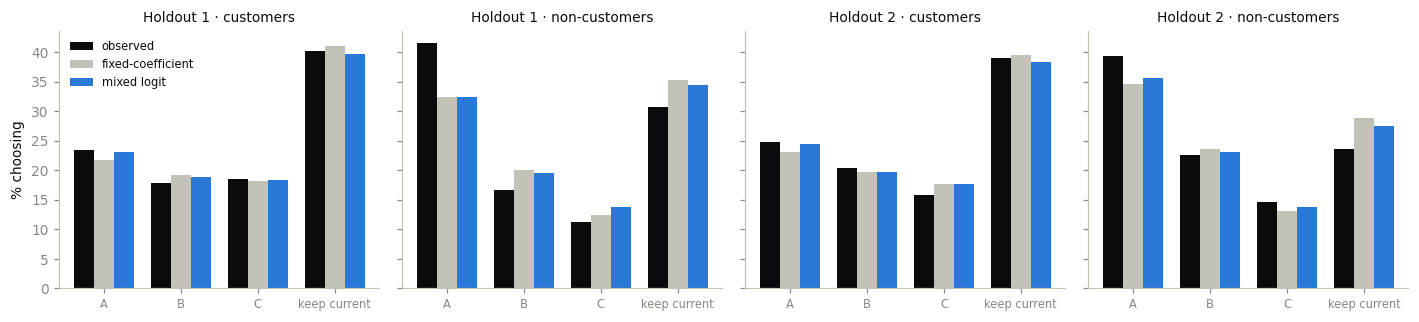

In [26]:
# Validate on Holdout Tasks
def holdout_probabilities(theta, Z, posterior = None):
    beta = random_coefficients(theta, Z, sp_noncustomer)
    V = np.einsum('ntjk,nrk->ntjr', X_holdout[..., :K_RANDOM], beta) + np.einsum('ntjk,k->ntj', X_holdout[..., K_RANDOM:], theta[2 * K_RANDOM:2 * K_RANDOM + len(SP_FIXED)])[..., None]
    P = softmax(V, axis = 2)
    return P.mean(axis = 3) if posterior is None else np.einsum('ntjr,nr->ntj', P, posterior)


def estimation_posterior(theta, Z, chunk = 1000):
    rows = []
    for start in range(0, len(Z), chunk):
        part = slice(start, start + chunk)
        beta = random_coefficients(theta, Z[part], sp_noncustomer[part])
        V = np.einsum('ntjk,nrk->ntjr', X_sp[part][..., :K_RANDOM], beta) + np.einsum('ntjk,k->ntj', X_sp[part][..., K_RANDOM:], theta[2 * K_RANDOM:2 * K_RANDOM + len(SP_FIXED)])[..., None]
        log_P = V - logsumexp(V, axis = 2, keepdims = True)
        log_seq = np.take_along_axis(log_P, y_sp[part][:, :, None, None], axis = 2)[:, :, 0, :].sum(axis = 1)
        rows.append(softmax(log_seq, axis = 1))
    return np.concatenate(rows)

posterior_250 = estimation_posterior(theta_sp, Z_250)
predictions = {
    'fixed-coefficient logit': holdout_probabilities(theta_fixed, Z_zero),
    'mixed logit, population': holdout_probabilities(theta_sp, Z_250),
    'mixed logit, individual': holdout_probabilities(theta_sp, Z_250, posterior_250),
}

is_customer = respondents.loc[sp_respondent_ids, 'is_customer'].to_numpy()
OPTIONS = ['A', 'B', 'C', 'keep current']
observed = np.eye(N_OPTIONS)[y_holdout]

scores = pd.DataFrame({
    name: {
        'hit rate': (P.argmax(axis = 2) == y_holdout).mean(),
        'log-likelihood per task': np.log(np.take_along_axis(P, y_holdout[:, :, None], axis = 2)).mean(),
        'share error, customers (MAE)': np.abs(P[is_customer].mean(axis = 0) - observed[is_customer].mean(axis = 0)).mean(),
        'share error, non-customers (MAE)': np.abs(P[~is_customer].mean(axis = 0) - observed[~is_customer].mean(axis = 0)).mean(),
    }
    for name, P in predictions.items()
}).T
display(scores.style.format({'hit rate': '{:.1%}', 'log-likelihood per task': '{:.3f}',
                             'share error, customers (MAE)': '{:.1%}', 'share error, non-customers (MAE)': '{:.1%}'})
        .set_caption('Holdout Tasks: Prediction Accuracy'))

fig, axes = plt.subplots(1, 4, figsize = (13, 3.0), sharey = True)
panels = [(t, group, mask) for t in range(2) for group, mask in [('customers', is_customer), ('non-customers', ~is_customer)]]
width = 0.26
for ax, (t, group, mask) in zip(axes, panels):
    x = np.arange(N_OPTIONS)
    ax.bar(x - width, observed[mask, t].mean(axis = 0) * 100, width, color = INK, label = 'observed')
    ax.bar(x, predictions['fixed-coefficient logit'][mask, t].mean(axis = 0) * 100, width, color = BASELINE, label = 'fixed-coefficient')
    ax.bar(x + width, predictions['mixed logit, population'][mask, t].mean(axis = 0) * 100, width, color = ACCENT, label = 'mixed logit')
    ax.set_xticks(x)
    ax.set_xticklabels(OPTIONS, fontsize = 7.5)
    ax.set_title(f'Holdout {t + 1} · {group}', fontsize = 9)
axes[0].set_ylabel('% choosing')
axes[0].legend(frameon = False, fontsize = 7.5)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · Individual-Level Part-Worths</h2>
<p><strong>Purpose:</strong> Estimates each respondent's own coefficients and willingness to pay, and shows how widely valuations vary.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Conditional Means.</strong> Each respondent's draws are weighted by how well they explain that respondent's 10 estimation choices; the weighted average is the respondent's part-worth.</li>
<li style="margin-bottom: 0.7em;"><strong>Willingness to Pay.</strong> A feature coefficient divided by the respondent's own price coefficient, averaged the same way, in dollars per line per month.</li>
<li style="margin-bottom: 0.7em;"><strong>Shrinkage.</strong> Ten choices cannot pin down seven coefficients, so conditional means are pulled toward the population. Individual estimates are for linking tastes to observables in section 04, not for targeting individuals.</li>
<li style="margin-bottom: 0.7em;"><strong>Survey Bias.</strong> Willingness to pay here inherits any understatement of price sensitivity in the survey; section 03 re-anchors price to real choices.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

,"customers, 10th pct","customers, median","customers, 90th pct","non-customers, median"
avoid 1 GB throttled,$0.62,$1.43,$2.94,$0.91
cover 1 GB of hotspot need,$0.15,$1.10,$2.74,$0.70
cover 1 roaming day,$2.90,$10.78,$24.95,$6.89
one streaming tier,-$1.21,$6.69,$19.09,$4.28
$1 of perks,$0.27,$0.59,$1.21,$0.38


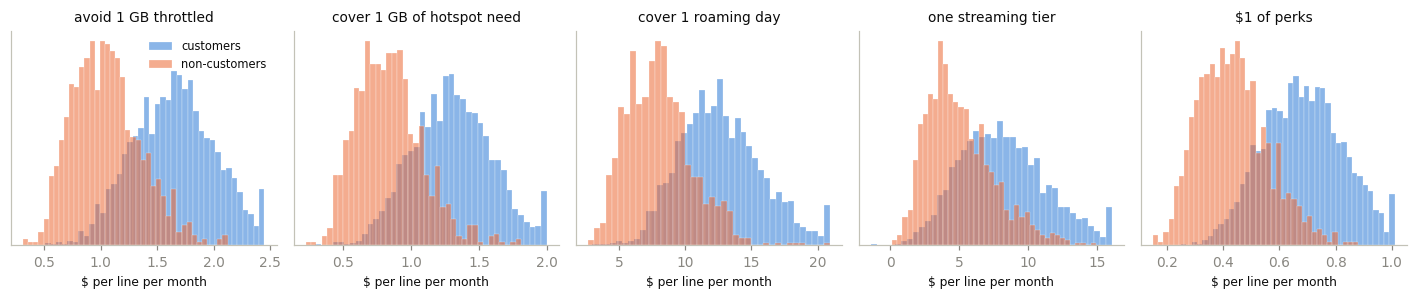

In [27]:
# Compute Individual Part-Worths
beta_draws = random_coefficients(theta_sp, Z_250, sp_noncustomer) / SP_SCALE[:K_RANDOM]
individual = pd.DataFrame(
    np.einsum('nr,nrk->nk', posterior_250, beta_draws), index = sp_respondent_ids, columns = [f'b_{k}' for k in SP_RANDOM]
)
WTP_TERMS = {
    'throttle': ('avoid 1 GB throttled', -1), 'hotspot': ('cover 1 GB of hotspot need', -1),
    'roam': ('cover 1 roaming day', -1), 'stream': ('one streaming tier', 1), 'perks': ('$1 of perks', 1),
}
for k, (label, sign) in WTP_TERMS.items():
    individual[f'wtp_{k}'] = np.einsum('nr,nr->n', posterior_250, sign * beta_draws[..., SP_RANDOM.index(k)] / -beta_draws[..., 0])
individual['is_customer'] = is_customer
individual['weight'] = sp_weights

population_draws = np.random.default_rng(SEED).standard_normal((1, 200_000, K_RANDOM))
population_beta = {
    group: random_coefficients(theta_sp, population_draws, np.array([flag]))[0] / SP_SCALE[:K_RANDOM]
    for group, flag in [('customers', 0.0), ('non-customers', 1.0)]
}


def population_wtp(group, k, sign, q):
    b = population_beta[group]
    return np.percentile(sign * b[:, SP_RANDOM.index(k)] / -b[:, 0], q)

wtp_summary = pd.DataFrame({
    label: {
        'customers, 10th pct': population_wtp('customers', k, sign, 10),
        'customers, median': population_wtp('customers', k, sign, 50),
        'customers, 90th pct': population_wtp('customers', k, sign, 90),
        'non-customers, median': population_wtp('non-customers', k, sign, 50),
    }
    for k, (label, sign) in WTP_TERMS.items()
}).T
display(wtp_summary.style.format(lambda v: f'-${-v:,.2f}' if v < 0 else f'${v:,.2f}')
        .set_caption('Willingness to Pay per Line per Month (stated preference, before price correction)'))

fig, axes = plt.subplots(1, len(WTP_TERMS), figsize = (13, 2.8))
for ax, (k, (label, _)) in zip(axes, WTP_TERMS.items()):
    values = individual[f'wtp_{k}']
    upper = values.quantile(0.99)
    for mask, color, name in [(individual['is_customer'], ACCENT, 'customers'), (~individual['is_customer'], ACCENT2, 'non-customers')]:
        ax.hist(values[mask].clip(upper = upper), bins = 40, density = True, alpha = 0.55, color = color, edgecolor = SURFACE, linewidth = 0.3, label = name)
    ax.set_title(label, fontsize = 9)
    ax.set_xlabel('$ per line per month', fontsize = 8)
    ax.set_yticks([])
axes[0].legend(frameon = False, fontsize = 7.5)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>6 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Saves the survey design, estimates, and individual part-worths that sections 03 and 04 build on.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li><code>sp_design</code>: every profile shown, with each respondent's feature values in per-dollar units, the choice, and the holdout flag</li>
<li><code>sp_respondents</code>: weights and the source of each respondent's demand estimate</li>
<li><code>sp_mixed_logit_estimates</code>: population estimates with robust standard errors</li>
<li><code>sp_individual_partworths</code>: conditional part-worths and willingness to pay by respondent</li>
</ol>
</div>

In [28]:
# Export Section 02 Outputs
exports = {
    'sp_design': pd.concat([sp[['respondent_id', 'task', 'option', 'is_holdout', 'chosen']], sp_features], axis = 1),
    'sp_respondents': respondents[['is_customer', 'current_plan', 'lines', 'weight']].join(respondent_demand).rename_axis('respondent_id').reset_index(),
    'sp_mixed_logit_estimates': sp_estimates.rename_axis('term').reset_index(),
    'sp_individual_partworths': individual.rename_axis('respondent_id').reset_index(),
}
paths = [save_output(df, name) for name, df in exports.items()]
display(pd.DataFrame({'rows': [len(df) for df in exports.values()], 'size (MB)': [round(p.stat().st_size / 1e6, 2) for p in paths]},
                     index = [p.name for p in paths]).rename_axis(None))

,rows,size (MB)
sp_design.parquet,192000,0.93
sp_respondents.parquet,4000,0.10
sp_mixed_logit_estimates.parquet,16,0.00
sp_individual_partworths.parquet,4000,0.50


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>03 · The Joint RP–SP Nested Model</h1>
<p><strong>Purpose:</strong> Combines revealed and stated choices in one model, so the survey supplies feature trade-offs, the history anchors real-world price sensitivity and plan constants, and a nested structure captures which plans substitute for which.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Stacked RP and SP likelihood with a relative scale parameter</td><td style="text-align: left; vertical-align: top;">Stated choices are noisier than real ones; the scale parameter lets both sources share coefficients without forcing equal noise.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">SP-specific price attenuation</td><td style="text-align: left; vertical-align: top;">Respondents understate price sensitivity; a separate SP price multiplier keeps that bias out of the forecast.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Nested logit, with price-tier and carrier trees compared</td><td style="text-align: left; vertical-align: top;">The substitution structure is estimated and tested rather than assumed.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Stacking Revealed and Stated Choices</h2>
<p><strong>Purpose:</strong> Puts both data sources on one alternative set and one feature definition.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>2 · Scale and Price Attenuation</h2>
<p><strong>Purpose:</strong> Estimates the relative noise of stated choices and the survey's understatement of price sensitivity.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>3 · Nest Structure: Price Tier vs Carrier</h2>
<p><strong>Purpose:</strong> Fits competing nesting trees and compares them on fit and on held-out switching patterns.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>4 · Substitution Diagnostics</h2>
<p><strong>Purpose:</strong> Shows where a new plan would draw from under the nested model versus a flat logit with the same coefficients.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>5 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Saves the joint model's coefficients and nesting parameters for sections 05 and 06.</p>
<p><em>To be built.</em></p>
</div>

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>04 · Latent Taste Classes</h1>
<p><strong>Purpose:</strong> Finds groups of customers who value features in distinctly different ways, and assigns every account to one using only carrier data, so the launch forecast and the recommendation can speak about segments rather than an average customer.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Latent class logit by expectation–maximization</td><td style="text-align: left; vertical-align: top;">Discrete classes with their own part-worths are easier to act on than a continuous distribution, and class count can be chosen on information criteria.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Class membership as a function of observables</td><td style="text-align: left; vertical-align: top;">Membership must be predictable from lines, device, usage, and roaming for the classes to be usable on the full base.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Scoring the customer base</td><td style="text-align: left; vertical-align: top;">Each account gets class probabilities, which the simulation uses in place of a single average taste.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Choosing the Number of Classes</h2>
<p><strong>Purpose:</strong> Fits two to six classes and selects on BIC, holdout fit, and interpretability.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>2 · Class Part-Worths and Willingness to Pay</h2>
<p><strong>Purpose:</strong> Profiles each class by what it will pay for data, hotspot, streaming quality, roaming, and perks.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>3 · Class Membership from Observables</h2>
<p><strong>Purpose:</strong> Links class probabilities to carrier data and measures how well membership can be predicted.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>4 · Scoring the Customer Base</h2>
<p><strong>Purpose:</strong> Assigns class probabilities to every account for the launch simulation.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>5 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Saves class part-worths, membership model, and scored accounts for notebook 02.</p>
<p><em>To be built.</em></p>
</div>